# Error Analysis
In this Notebook we will explore where our model fails and find out ways to improve our models performance

- Train vs Test Prediction 
- Residual Analysis
- Feature based roc_auc performance
- Feature importance

In [17]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import time
import random
import statistics
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
sys.path.append('..')  
from src.evaluation.evaluation_metrics import EvaluationMetrics
from sklearn.metrics import roc_auc_score
from src.models.xgb.config import OHE_COLS, FREQUENCY_COLS


from src.data.loader import Loader
from src.data.splitter import split_data

loader = Loader().load()
X_train, X_test, y_train, y_test= split_data(loader.df)

In [18]:
model_path = Path.cwd().parent / "src" / "models" / "xgb" / "pipeline.pkl"
pipeline:Pipeline = joblib.load(filename=model_path)

## Train vs Test Set

In this section we compare the models performance on the trainingsset to the test set.
We try to figure out if the model is overfitting the data


In [19]:
y_train_pred = pipeline.predict_proba(X_train)[:, 1]
xgb_guessing_metrics = EvaluationMetrics(y=y_train, y_pred=y_train_pred)

In [20]:
y_test_pred = pipeline.predict_proba(X_test)[:, 1]
xgb_test_guessing_metrics = EvaluationMetrics(y=y_test, y_pred=y_test_pred)

In [21]:
xgb_guessing_metrics.print_eval_report(headline="Train Set")


Train Set
- Precision: 0.18407409099214325
- Recall: 0.9710825953370685
- F1: 0.3094838096518091
- ROC-AUC: 0.9791662745120762


In [22]:
xgb_test_guessing_metrics.print_eval_report(headline="Test Set")


Test Set
- Precision: 0.1573254221816522
- Recall: 0.8481791338582677
- F1: 0.2654192654192654
- ROC-AUC: 0.919471123971491


After adjusting and intensively improving features and regularization, the model is still overfitting.

## Residual Analysis
in this section we create a new df containing the true value y, our predicted value y^ and its difference

In [23]:
residuals = y_test - y_test_pred

error_df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_test_pred,
    'residual': residuals
})

In [24]:
error_df["residual"].mean()

np.float64(-0.15004932216774544)

In [25]:
error_df["y_pred"].mean()

np.float32(0.18445851)

In [26]:
error_df["y"].mean()

np.float64(0.034409184813899145)

In [27]:
fraud_residuals   = error_df[error_df.y == 1]["residual"] # residuals for target = 1
legit_residuals   = error_df[error_df.y == 0]["residual"] # residuals for target = 0

print(f"Fraud Mean Residual: {fraud_residuals.mean():.4f}")   # should be extremely positive (constantly undererstimating y)
print(f"Legit Mean Residual: {legit_residuals.mean():.4f}")   


Fraud Mean Residual: 0.3156
Legit Mean Residual: -0.1666


The model consistently underestimates fraud probability, meaning too many fraudulent payments are not being detected.

On average the model predicts ~18% fraud risk across all samples, while the true fraud rate is only ~3.4% — suggesting the model is overcautious in the positive direction but still misses many actual fraud cases at higher thresholds.

## Feature Based ROC Analysis
In this section we compare different feature values and their average ROC score.

This helps identify which feature segments the model handles well and which it struggles with.

### Categorical Features

We group categorical columns by encoding type (OHE vs. frequency) and compute ROC-AUC on the subset of rows that belong to each category. This reveals whether the model struggles with specific feature values rather than performing poorly across the board.

In [28]:
cat_cols = X_test.select_dtypes(include='object').columns.tolist()

/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_51172/3632854767.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_test.select_dtypes(include='object').columns.tolist()


In [29]:
print(cat_cols)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [ ]:
results = []
"""
loop over each column in the assigned column and create a subarray of rows (boolean based in mask)
where each value for that specific column matches. Than check performance based on this subset
and create evaluation metrics. This helps us to understand if certain column values create noise or
difficulties for the model.
"""

for group_name, cols in [("FREQ", FREQUENCY_COLS), ("OHE", OHE_COLS)]:
    for col in cols:
        for category in X_test[col].dropna().unique():
            mask = (X_test[col] == category).values
            
            if mask.sum() < 1000:
                continue
            if len(np.unique(y_test.values[mask])) < 2:
                continue
                
            auc = roc_auc_score(y_test.values[mask], y_test_pred[mask])
            results.append({
                "encoding":   group_name,
                "feature":    col,
                "category":   category,
                "roc":        auc,
                "n_samples":  mask.sum(),
            })

df_results = pd.DataFrame(results).sort_values("auc")
print(df_results.head(20))  # print worse 20 categorical features


   encoding        feature             category       auc  n_samples
17     FREQ          id_31  ie 11.0 for desktop  0.733362       1175
13     FREQ          id_30            Windows 7  0.749968       1601
35      OHE          card4             discover  0.807638       1257
49      OHE             M5                    T  0.858423      22982
56      OHE             M8                    T  0.864382      25642
52      OHE             M6                    F  0.874680      48855
57      OHE             M9                    T  0.879509      59924
54      OHE             M7                    T  0.879631       9575
42      OHE             M2                    T  0.881728      75461
50      OHE             M5                    F  0.881800      28158
44      OHE             M3                    T  0.882913      66951
53      OHE             M7                    F  0.883083      62248
47      OHE             M4                   M0  0.883986      41334
30      OHE      ProductCD        

We can clearly see certain features performing worse than others. Most of the features have little to no relevance for the model (M1-M9).

Product W is performing worse than other products in the same column.

In [33]:
df_results.groupby("encoding")["auc"].mean()

encoding
FREQ    0.923667
OHE     0.909449
Name: auc, dtype: float64

we can see small to no difference at all comparing the different feature engineering methods performed on the categorical features

### Numerical Features

For numeric columns, we bin values into 5 quantile buckets and measure ROC-AUC per bucket. This shows whether model performance degrades at specific value ranges — for example, whether it handles low-value transactions differently from high-value ones.

In [ ]:
numerical_cols = X_test.select_dtypes(include="number").columns.tolist()

results = []

for col in numerical_cols:
    # cut column values to 5 bins 
    bins = pd.qcut(X_test[col], q=5, duplicates="drop")
    
    for bin_label in bins.dropna().unique():
        mask = (bins == bin_label).values
        
        if mask.sum() < 1000:
            # if bin group has less than 1000 examples skip
            continue
        if len(np.unique(y_test.values[mask])) < 2:
            # if bin groups has less than 2 unique values skip
            continue
        
        auc = roc_auc_score(y_test.values[mask], y_test_pred[mask])
        results.append({
            "feature":  col,
            "bin":      str(bin_label),
            "roc":      auc,
            "n_samples": mask.sum(),
        })

df_num_results = pd.DataFrame(results).sort_values("auc")
print(df_num_results.head(25))


    feature               bin       auc  n_samples
251     V75        (1.0, 3.0]  0.662463       1042
219     V53        (1.0, 4.0]  0.761745       1398
253     V76        (1.0, 5.0]  0.767536       2745
163     V13        (1.0, 6.0]  0.803748       2668
625   id_01       (-5.0, 0.0]  0.805847       1727
221     V54        (1.0, 4.0]  0.806882       3300
89       D2    (-0.001, 19.0]  0.816180      14001
150      V6        (1.0, 9.0]  0.822325       4261
142      V2        (1.0, 8.0]  0.828781       4304
152      V7        (1.0, 9.0]  0.833728       6352
194     V36        (1.0, 5.0]  0.836459       2281
127     D11    (-0.001, 21.0]  0.841991      34085
540    V282       (1.0, 16.0]  0.847681      12207
45    dist2  (226.0, 10237.0]  0.851791       1098
181     V26        (1.0, 4.0]  0.853958       1302
542    V283       (1.0, 56.0]  0.854642      19156
576    V310     (39.0, 175.0]  0.858580      23626
138     D15    (152.0, 437.0]  0.860662      21369
599    V326       (1.0, 31.0]  

In [35]:
for col in ["D2", "D11", "C2"]:
    bins = pd.qcut(X_test[col], q=5, duplicates="drop")
    grouped = pd.DataFrame({
        "bin": bins,
        "fraud": y_test.values
    }).groupby("bin")["fraud"].mean()
    print(f"\n{col}:")
    print(grouped)


D2:
bin
(-0.001, 19.0]    0.052925
(19.0, 62.0]      0.021605
(62.0, 150.0]     0.018583
(150.0, 343.0]    0.013059
(343.0, 639.0]    0.007880
Name: fraud, dtype: float64

D11:
bin
(-0.001, 21.0]    0.026669
(21.0, 137.0]     0.019534
(137.0, 385.0]    0.014808
(385.0, 670.0]    0.007862
Name: fraud, dtype: float64

C2:
bin
(-0.001, 1.0]    0.023468
(1.0, 2.0]       0.028860
(2.0, 4.0]       0.031549
(4.0, 1670.0]    0.078160
Name: fraud, dtype: float64


## Feature Importance

We extract XGBoost's built-in feature importance (`weight` metric: how often a feature is used for a split across all trees). This gives us a ranking of which features the model actually relies on, and which ones can likely be dropped without hurting performance.

In [42]:
model = pipeline.named_steps["model"]

# select first row of test set 
Xt = X_test.iloc[:1].copy()
# apply all transformation steps, exclude model
for name, step in pipeline.steps[:-1]:
    Xt = step.transform(Xt)

# extract all columns after transformation
feature_names = Xt.columns  

# print column importance (top 20)
importances = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importances.head(20))


addr2                0.211831
ProductCD_C          0.206562
C8                   0.038303
V_pca_1              0.036461
C4                   0.027638
ProductCD_W          0.024340
id_12_NotFound       0.018185
C14                  0.014920
id_12_Found          0.014250
C5                   0.012977
card6_debit          0.012151
C1                   0.009934
D2                   0.009560
Trans_amt_isround    0.008468
C13                  0.008126
card6_credit         0.007203
M5_T                 0.007101
C12                  0.006919
C11                  0.006627
id_17                0.006605
dtype: float32


In [ ]:
# 20 most useless columns
print(importances.tail(20)) # => think about dropping them

id_27_Found                 0.002258
id_37_T                     0.002221
DT_weekday_cos              0.002098
id_29_Found                 0.002062
M1_T                        0.002062
DT_weekday_sin              0.001978
id_19                       0.001975
id_16_NotFound              0.001964
id_23_IP_PROXY:ANONYMOUS    0.001881
id_35_T                     0.001873
id_28_New                   0.001803
id_16_Found                 0.001743
id_29_NotFound              0.001588
id_34_match_status:-1       0.000000
M1_F                        0.000000
id_34_match_status:0        0.000000
card6_charge card           0.000000
card6_debit or credit       0.000000
id_27_NotFound              0.000000
id_23_IP_PROXY:HIDDEN       0.000000
dtype: float32


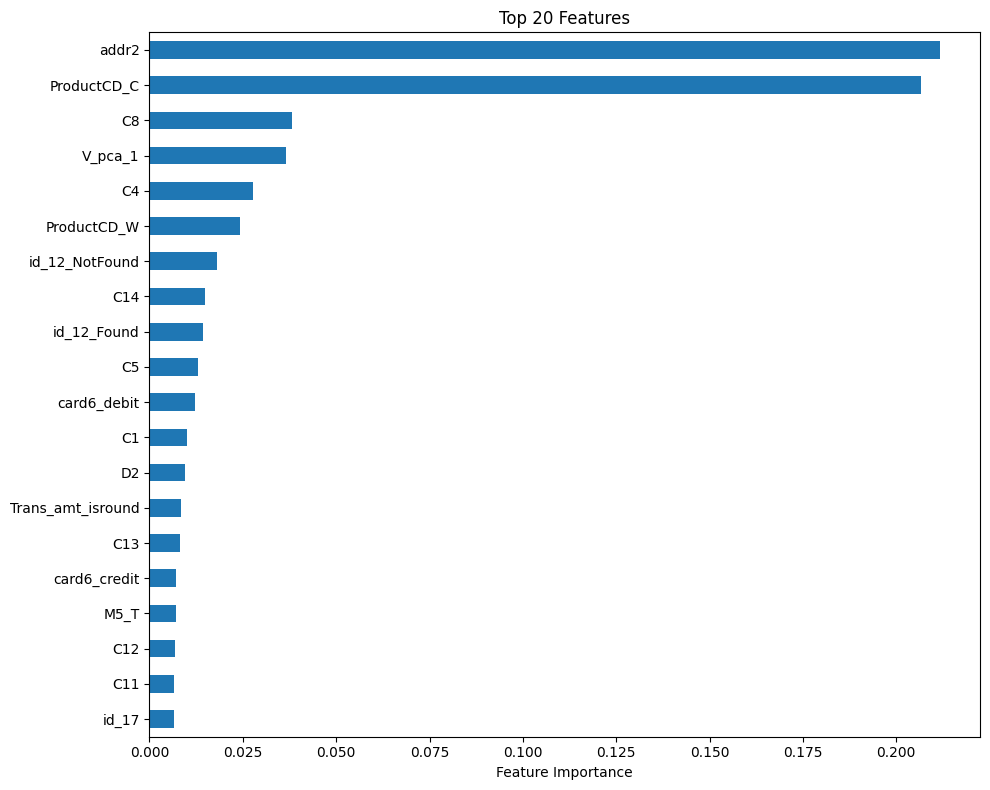

In [43]:
importances.head(20).plot.barh(figsize=(10, 8))
plt.xlabel("Feature Importance")
plt.title("Top 20 Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Summary

The error analysis reveals that the model, while strong in aggregate (ROC-AUC ~0.92), has several structural weaknesses worth addressing.

**Overfitting** is visible: train ROC-AUC is ~0.98 versus test ROC-AUC of ~0.92. The gap persisted even after regularization adjustments, likely because the fraud signal is sparse relative to the number of features. Further regularization (lower `max_depth`, higher `min_child_weight`) or dropping low-importance features are the most direct levers.

**Residual bias** shows that the model consistently underestimates fraud probability for actual fraud cases (mean fraud residual: +0.32). This is partly compensated by the lowered decision threshold (0.3 instead of 0.5), but the root cause is the class imbalance — the model is trained on 96.5% negative examples and tends to be conservative with its positive predictions.

**Feature importance** is highly concentrated: `addr2` and `ProductCD_C` together account for ~42% of all splits, while many M-flags and identity columns contribute near zero.

**Categorical segment analysis** shows the worst performance on IE 11 users and Windows 7 devices — small, noisy subsets likely underrepresented in training. Product W has the lowest AUC among ProductCD categories and may benefit from dedicated feature engineering. The near-identical mean AUC between OHE and frequency-encoded columns (0.909 vs. 0.924) confirms that both encoding strategies are roughly equivalent and neither is clearly superior.